# Tutorial 1: Quantum Error Correction with Shor's Code

How can we protect a qubit against both bit-flip and phase-flip errors?

In this notebook, we build Shor's nine-qubit code using **Stim** and use a memory experiment to study how well it preserves encoded quantum information.

We assume familiarity with qubits, Pauli operators, Hadamard and CNOT gates, and the three-qubit repetition code.

## From repetition codes to Shor's code

The three-qubit bit-flip repetition code uses the codewords $|000\rangle$ and $|111\rangle$. It can correct a single bit-flip error, represented by $X$, but cannot correct an unknown single-qubit phase-flip error, represented by $Z$.

Changing to the $X$ basis exchanges the roles of these errors:

$$
|+\rangle = \frac{|0\rangle + |1\rangle}{\sqrt{2}},
\qquad
|-\rangle = \frac{|0\rangle - |1\rangle}{\sqrt{2}},
$$

$$
Z|+\rangle = |-\rangle,
\qquad
Z|-\rangle = |+\rangle.
$$

A phase flip therefore looks like a bit flip in this basis. The repetition code with codewords $|+++\rangle$ and $|---\rangle$ protects against phase flips, but changing the basis alone does not protect against both error types.

Shor's code combines the two repetition codes through **concatenation**: first encode against phase flips, then encode each of the resulting three qubits against bit flips.

Define the three-qubit states

$$
|G_{\pm}\rangle =
\frac{|000\rangle \pm |111\rangle}{\sqrt{2}}.
$$

The resulting nine-qubit logical codewords are

$$
|0_L\rangle = |G_+\rangle^{\otimes 3},
\qquad
|1_L\rangle = |G_-\rangle^{\otimes 3}.
$$

An arbitrary logical qubit is encoded as

$$
|\psi_L\rangle = \alpha|0_L\rangle + \beta|1_L\rangle,
\qquad
|\alpha|^2 + |\beta|^2 = 1.
$$

9 physical qubits encoded as 1 logical qubit. The construction protects quantum superpositions as well as logical basis states.

## What do the checks measure?

We label the physical qubits $0,\ldots,8$ and group them into three blocks:

$$
(0,1,2), \qquad (3,4,5), \qquad (6,7,8).
$$

Within each block, $Z$-type parity checks, e.g. $Z_0Z_1, Z_1Z_2, ...$, detect bit flips. Across blocks, $X$-type parity checks, i.e. $X_0X_1X_2,X_3X_4X_5, X_6X_7X_8$, detect phase flips.

These commuting checks are the code's **stabilizer generators**. Their measurement outcomes form an **error syndrome**, which provides information for choosing a correction without revealing the encoded amplitudes $\alpha$ and $\beta$.

We will construct these checks explicitly and use them to correct single-qubit $X$, $Z$, and $Y$ errors.

## Why is this a distance-3 code?

The **weight** of a Pauli operator is the number of qubits on which it acts nontrivially.

The **code distance** is the smallest weight of a Pauli operator that preserves the code space while acting nontrivially on the encoded qubit. Such an operator is an undetectable logical operation.

For the codeword convention above, one logical bit-flip operator is

$$
\overline{X} = Z_0Z_3Z_6.
$$

Each physical $Z$ exchanges $|G_+\rangle$ and $|G_-\rangle$ in its block, so

$$
\overline{X}|0_L\rangle = |1_L\rangle,
\qquad
\overline{X}|1_L\rangle = |0_L\rangle.
$$

This weight-three operator shows that $d \leq 3$. We will also verify that no Pauli operator of weight one or two acts as a nontrivial logical operator, establishing $d=3$.

Shor's code therefore has parameters

$$
[[n,k,d]] = [[9,1,3]]:
$$

nine physical qubits encode one logical qubit with distance three. With ideal syndrome extraction and recovery, it can correct an arbitrary error affecting any one physical qubit.

## What we will do

Our main goal is to implement and understand a quantum memory experiment:

1. **Prepare** logical states in the logical $Z$ and $X$ bases.
2. **Define** the stabilizers, inject Pauli errors and inspect their syndromes.
4. **Decode** each syndrome and track the inferred correction classically as a Pauli frame.
5. **Read out** the corresponding logical observable, accounting for the Pauli frame.
6. **Repeat** with random errors to estimate logical failure probabilities as the physical error probability changes.

In this notebook, we work with noisy data qubits and ideal encoding, syndrome measurements, and readout. These assumptions let us isolate the behavior of the code and decoder.

<!-- A memory experiment measures how often the stored logical information survives; it does not guarantee an error-free logical qubit. We will report logical $Z$- and $X$-basis failures separately, since a single measurement basis cannot reveal every logical error. -->

<!-- ## Extensions: logical operations and simulation

Once the memory experiment works, we will apply logical Pauli operations and verify their effects on the final readout.

We will also connect the circuit to the stabilizer description used by Stim. For Clifford gates, Pauli operators remain Pauli operators under conjugation:

$$
P \longmapsto UPU^\dagger.
$$

This lets us track stabilizers instead of explicitly storing every amplitude of the quantum state. We will distinguish this forward stabilizer update from the Heisenberg-picture transformation of an observable,

$$
O \longmapsto U^\dagger O U,
$$

and use these viewpoints to introduce Stim's tableau representation. -->

In [30]:
import stim
from IPython.display import display, Markdown

## 1. Preparing the logical states

We use qubits numbered $0,\ldots,8$, grouped into three blocks:

$$
(0,1,2), \qquad (3,4,5), \qquad (6,7,8).
$$

Qubit $0$ initially holds the state $\alpha|0\rangle+\beta|1\rangle$. The other eight qubits start in $|0\rangle$.

Our encoder implements

$$
\left(\alpha|0\rangle+\beta|1\rangle\right)_0
\otimes |0\rangle^{\otimes 8}
\longmapsto
\alpha|0_L\rangle+\beta|1_L\rangle,
$$

where

$$
|0_L\rangle =
\left(\frac{|000\rangle+|111\rangle}{\sqrt{2}}\right)^{\otimes 3},
\qquad
|1_L\rangle =
\left(\frac{|000\rangle-|111\rangle}{\sqrt{2}}\right)^{\otimes 3}.
$$

The circuit has three stages:

1. **Encode across the block leaders.** Apply CNOTs from qubit $0$ to qubits $3$ and $6$. Their joint state becomes $\alpha|000\rangle_{0,3,6}+\beta|111\rangle_{0,3,6}$: the input information is stored in a superposition of the two repetition-code words.

2. **Change to the $X$ basis.** Apply Hadamard gates to the three block leaders, giving $\alpha|+++\rangle_{0,3,6}+\beta|---\rangle_{0,3,6}$. This forms the phase-flip repetition encoding, since a $Z$ error exchanges $|+\rangle$ and $|-\rangle$.

3. **Encode within each block.** Apply CNOTs from each block leader to the other two qubits in its block:
   
   $$
   |\pm\rangle|00\rangle
   \longmapsto
   \frac{|000\rangle\pm|111\rangle}{\sqrt{2}}.
   $$
   
   This adds bit-flip protection within each block and produces the final state $\alpha|0_L\rangle+\beta|1_L\rangle$.

In [3]:
# Define the Shor's code encoder circuit using Stim.
# TICK marks a boundary between circuit layers in Stim, making the circuit diagram easier to read.
encoder = stim.Circuit("""
    CX 0 3
    CX 0 6
    TICK

    H 0 3 6
    TICK

    CX 0 1 3 4 6 7
    TICK

    CX 0 2 3 5 6 8
""")

In [5]:
def prepare_shor(state="0"):
    """Prepare |0_L>, |1_L>, |+_L>, or |-_L> on qubit 0-8."""
    if state not in ("0", "1", "+", "-"):
        raise ValueError("state must be '0', '1', '+', or '-'")

    circuit = stim.Circuit()

    # Reset all nine qubits to |0>.
    circuit.append("R", range(9))

    # Prepare the unencoded input on qubit 0.
    # |1>: X|0>; |+>: H|0>; |->: HX|0>.
    if state in ("1", "-"):
        circuit.append("X", [0])
    if state in ("+", "-"):
        circuit.append("H", [0])

    circuit.append("TICK")

    # Apply the same encoder to each input.
    circuit += encoder
    return circuit

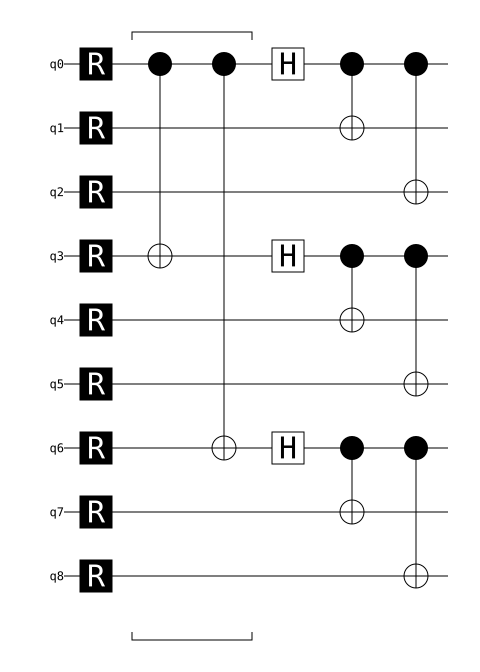

In [6]:
preparation = prepare_shor("0")  # Try "1", "+", or "-".

display(preparation.diagram("timeline-svg"))

simulator = stim.TableauSimulator()
simulator.do(preparation)

## 2. Defining the stabilizers

Stabilizers are Pauli operators that leave every valid encoded state unchanged:

$$
S_i|\psi_L\rangle = |\psi_L\rangle.
$$

An $[[n,k,d]]$ stabilizer code has $n-k$ independent stabilizer generators. Each imposes a $+1$ constraint that halves the allowed state-space dimension:

$$
2^n \longrightarrow 2^{n-(n-k)}=2^k.
$$

Shor's $[[9,1,3]]$ code therefore has eight independent generators, leaving a two-dimensional code space for one logical qubit. These generators commute, so we can measure them together without disturbing the encoded information.

The six $Z$-type generators compare qubits within each block:

$$
\begin{aligned}
\text{Block 1}: Z_0Z_1, Z_1Z_2,\\
\text{Block 2}: Z_3Z_4, Z_4Z_5,\\
\text{Block 3}: Z_6Z_7, Z_7Z_8.
\end{aligned}
$$

These checks detect bit flips: an $X$ error changes the sign of any $Z$-type check that acts on the affected qubit.

The three pairwise $X$-type checks compare the signs of the three blocks:

$$
\begin{aligned}
S_{X,1} &= X_0X_1X_2X_3X_4X_5,\\
S_{X,2} &= X_3X_4X_5X_6X_7X_8,\\
S_{X,3} &= X_0X_1X_2X_6X_7X_8.
\end{aligned}
$$

Only two are independent: $S_{X,3}=S_{X,1}S_{X,2}$. Any two therefore generate all three, so we need only two $X$-type generators. These checks detect phase flips: a $Z$ error changes the sign of any $X$-type check that acts on the affected qubit.

For an error-free encoded state, every check has outcome $+1$. An outcome of $-1$ indicates a violated check. Together, the eight outcomes form the **error syndrome**.

### Deriving the stabilizers with Stim

Given the encoder circuit, Stim can derive the stabilizers automatically. The idea is to track how the encoder transforms the known stabilizers of the input qubits.

Before encoding, qubits $1,\ldots,8$ are in $|0\rangle$, so each is stabilized by $Z_i$. After applying the encoder $U$, these become the code generators:

$$
S_i = UZ_iU^\dagger,
\qquad i=1,\ldots,8.
$$

This operator-tracking approach is closely related to the **Heisenberg picture**. Here we propagate stabilizers forward as $USU^\dagger$; the usual Heisenberg convention propagates observables backward as $U^\dagger O U$.

Because our encoder uses only Clifford gates, each transformed operator remains a Pauli string. Stim stores the transformations of $X_i$ and $Z_i$ in a **tableau**; `tableau.z_output(i)` returns $UZ_iU^\dagger$.

For example, start with $Z_3$, which stabilizes input qubit $3$. The CNOT from qubit $0$ to qubit $3$ transforms it into $Z_0Z_3$. The Hadamards then turn these $Z$ operators into $X$ operators, and the within-block CNOTs spread each $X$ to the other qubits in its block:

$$
Z_3
\xrightarrow{\mathrm{CNOT}_{0\to3}}
Z_0Z_3
\xrightarrow{H_0H_3}
X_0X_3
\xrightarrow{\text{within-block CNOTs}}
X_0X_1X_2X_3X_4X_5.
$$

Thus $UZ_3U^\dagger=S_{X,1}$: the initial single-qubit stabilizer becomes a check comparing the first two blocks. Gates that leave the operator unchanged are omitted from the sequence above.

The resulting generators may differ from those listed above, but generate the same stabilizer group. Qubit $0$ carries the logical input, so its transformed $X_0$ and $Z_0$ give the logical operators instead.

In [ ]:
tableau = stim.Tableau.from_circuit(encoder)

stabilizers = {
    f"S{i}": tableau.z_output(i)
    for i in range(1, 9)
}

for name, operator in stabilizers.items():
    print(f"{name}: {operator}")
    # In the printout, _ means identity

S1: +ZZ_______
S2: +Z_Z______
S3: +XXXXXX___
S4: +___ZZ____
S5: +___Z_Z___
S6: +XXX___XXX
S7: +______ZZ_
S8: +______Z_Z


### Logical operators

We excluded qubit $0$ when generating the code stabilizers because it carries the logical input. Unlike the other eight qubits, its state is not fixed to $|0\rangle$.

Its Pauli operators instead become the logical operators under encoding:

$$
\overline{Z}=UZ_0U^\dagger=X_0X_1X_2,
\qquad
\overline{X}=UX_0U^\dagger=Z_0Z_3Z_6.
$$

(**TODO**: Prove this.)

Although $\overline{X}$ consists of physical $Z$ operators, it exchanges the logical codewords:

$$
\overline{X}|0_L\rangle=|1_L\rangle,
\qquad
\overline{X}|1_L\rangle=|0_L\rangle.
$$

Similarly, $\overline{Z}$ changes their relative phase:

$$
\overline{Z}|0_L\rangle=|0_L\rangle,
\qquad
\overline{Z}|1_L\rangle=-|1_L\rangle.
$$

To observe this phase change, we use superpositions: $\overline{Z}$ exchanges $|+_L\rangle$ and $|-_L\rangle$.

The following cell applies each operator and checks that the resulting state matches the expected logical state, up to global phase.

In [26]:
tableau = stim.Tableau.from_circuit(encoder)
logical_z = tableau.z_output(0)
logical_x = tableau.x_output(0)

print("Logical Z:", logical_z)
print("Logical X:", logical_x)

examples = [
    ("X", logical_x, "0", "1"),
    ("X", logical_x, "1", "0"),
    ("Z", logical_z, "+", "-"),
    ("Z", logical_z, "-", "+"),
]

for label, operator, initial, expected in examples:
    actual = stim.TableauSimulator()
    actual.do(prepare_shor(initial)) # Prepare the initial logical state
    actual.do_pauli_string(operator) # Apply the logical operator

    reference = stim.TableauSimulator()
    reference.do(prepare_shor(expected)) # Prepare the expected logical state

    # Equal canonical stabilizers mean equal states up to global phase.
    assert actual.canonical_stabilizers() == reference.canonical_stabilizers()
    print(f"{label}_L |{initial}_L> = |{expected}_L> : ✅")

Logical Z: +XXX______
Logical X: +Z__Z__Z__
X_L |0_L> = |1_L> : ✅
X_L |1_L> = |0_L> : ✅
Z_L |+_L> = |-_L> : ✅
Z_L |-_L> = |+_L> : ✅


### Injecting errors and inspecting syndromes

Suppose error $E$ occurs, if $E$ commutes with a stabilizer, its outcome remains $+1$. If it anticommutes, the outcome becomes $-1$:
$$
S_iE|\psi_L\rangle =
\begin{cases}
+E|\psi_L\rangle, & S_iE=ES_i,\\
-E|\psi_L\rangle, & S_iE=-ES_i.
\end{cases}
$$
We represent these outcomes as syndrome bits: $+1\leftrightarrow 0$ and $-1\leftrightarrow 1$.

An $X$ error can flip $Z$-type checks, a $Z$ error can flip $X$-type checks, and a $Y$ error can flip both. 

For a combination of Pauli errors, the syndrome is the bitwise XOR of their individual syndromes:

$$
\mathbf{s}(E_1E_2)
=
\mathbf{s}(E_1)\oplus\mathbf{s}(E_2).
$$

A check therefore flips when an **odd** number of the error factors anticommute with it; an even number cancels out.

In [27]:
def inspect_syndrome(error):
    simulator = stim.TableauSimulator()
    simulator.do(prepare_shor("0")) # Initial 0 logical state
    simulator.do_pauli_string(error) # Insert the error

    syndrome = []
    for operator in stabilizers.values(): # Check each stabilizer
        expectation = simulator.peek_observable_expectation(operator)
        assert expectation in (-1, 1)
        syndrome.append((1 - expectation) // 2)

    return syndrome


# String positions correspond to qubits 0–8.
errors = {
    "None": stim.PauliString("IIIIIIIII"),
    "X0": stim.PauliString("XIIIIIIII"),
    "X2": stim.PauliString("IIXIIIIII"),
    "X0 X2": stim.PauliString("XIXIIIIII"),
    "X2 Z4 Y7": stim.PauliString("IIXIZIIYI"),
    "Logical X": logical_x,
}

print("Error       " + " ".join(stabilizers))

for label, error in errors.items():
    bits = inspect_syndrome(error)
    print(f"{label:<12}" + "  ".join(map(str, bits)))

# Verify the XOR rule for X0 X2.
s0 = inspect_syndrome(errors["X0"])
s1 = inspect_syndrome(errors["X2"])
combined = inspect_syndrome(errors["X0 X2"])

assert combined == [a ^ b for a, b in zip(s0, s1)]
print(f"Syndrome of X0 XOR X2 = X0 X2 : ✅")

Error       S1 S2 S3 S4 S5 S6 S7 S8
None        0  0  0  0  0  0  0  0
X0          1  1  0  0  0  0  0  0
X2          0  1  0  0  0  0  0  0
X0 X2       1  0  0  0  0  0  0  0
X2 Z4 Y7    0  1  1  0  0  1  1  0
Logical X   0  0  0  0  0  0  0  0
Syndrome of X0 XOR X2 = X0 X2 : ✅


## 3. Decoding and tracking corrections

A decoder maps the syndrome to a recovery operator $C$. Its goal is to restore the logical information, not necessarily identify the exact physical error $E$.

Recovery succeeds when

$$
CE \in \mathcal{S},
$$

up to global phase, where $\mathcal{S}$ is the stabilizer group. Thus, different errors can require the same recovery.

### Correcting errors in Shor's code

- **Bit flips:** The $Z$-type checks compare qubits within each block. Assuming at most one bit flip per block, their syndrome selects an $X$ correction on the disagreeing qubit.
- **Phase flips:** The $X$-type checks compare blocks. Assuming at most one block has odd phase-flip parity, their syndrome selects that block. A $Z$ correction on any qubit in that block has the same effect on the encoded information.
- **Combined errors:** Combine the $X$ and $Z$ corrections. This also handles a single-qubit $Y$ error, since $Y=iXZ$.

For example, if $E=Z_1$, choosing $C=Z_0$ succeeds because

$$
CE=Z_0Z_1\in\mathcal{S}.
$$

The correction does not need to target the qubit where the error occurred.

Our lookup decoder chooses a minimum-weight recovery consistent with the syndrome. It searches $X$, $Y$, and $Z$ errors jointly, so its choices can differ from correcting the two error types separately.

### Tracking a Pauli frame

Instead of applying recovery gates physically, we can record the pending correction in a classical **Pauli frame** $F$. Starting from $F=I$, a recovery updates it as

$$
F \leftarrow CF,
$$

ignoring global phase.

For a final Pauli measurement $M$, we interpret its raw bit using

$$
m_{\mathrm{corrected}}
=
m_{\mathrm{raw}}\oplus
\begin{cases}
0, & FM=MF,\\
1, & FM=-MF.
\end{cases}
$$

This changes our interpretation of the measurement without applying a correction gate. If further Clifford gates are applied, the frame must also be propagated through them.

In [21]:
from itertools import combinations, product

def syndrome_of(error):
    """Compute a Pauli error's syndrome from its commutation relations."""
    return tuple(
        int(not error.commutes(check))
        for check in stabilizers.values()
    )
recovery_table = {}

for weight in range(10):
    for qubits in combinations(range(9), weight):
        for paulis in product("XYZ", repeat=weight):
            candidate = stim.PauliString(9)

            for qubit, pauli in zip(qubits, paulis):
                candidate[qubit] = pauli

            # Keep the first candidate: it has minimum weight.
            recovery_table.setdefault(syndrome_of(candidate), candidate)

    if len(recovery_table) == 2 ** len(stabilizers):
        break

print(f"Recovery table covers {len(recovery_table)} syndromes.")

Recovery table covers 256 syndromes.


In [22]:
def decoding_trial(error, state, observable):
    simulator = stim.TableauSimulator()
    simulator.do(prepare_shor(state))
    simulator.do_pauli_string(error)

    # Inspect the ideal syndrome, as in the previous section.
    syndrome = tuple(
        (1 - simulator.peek_observable_expectation(check)) // 2
        for check in stabilizers.values()
    )

    # The decoder receives only the syndrome.
    correction = recovery_table[syndrome]

    # Each experiment starts with an identity Pauli frame.
    # Record the recovery without physically applying it.
    frame = stim.PauliString(9)
    frame = correction * frame

    # Measure the logical observable and adjust its classical result.
    raw_bit = int(simulator.measure_observable(observable))
    flip_bit = int(not frame.commutes(observable))
    corrected_bit = raw_bit ^ flip_bit

    # Simulation-only evaluation; the decoder cannot access this error.
    residual = frame * error

    syndrome_cleared = all(
        residual.commutes(check)
        for check in stabilizers.values()
    )

    # With zero residual syndrome, commuting with both logical Paulis
    # means the residual is a stabilizer, up to global phase.
    logical_restored = (
        syndrome_cleared
        and residual.commutes(logical_x)
        and residual.commutes(logical_z)
    )

    return syndrome, frame, raw_bit, corrected_bit, syndrome_cleared, logical_restored


def describe_error(error):
    """Display a Pauli string as qubit-labelled operators."""
    return " ".join(
        f"{'IXYZ'[error[q]]}{q}"
        for q in range(len(error))
        if error[q] != 0
    ) or "I"


In [31]:
rows = [
    "| Error | Syndrome | Tracked correction | Residual 0 | Logical information restored |",
    "|---|---|---|---|---|",
]

for label, error in errors.items():
    syndrome, frame, _, _, cleared, restored = decoding_trial(
        error, "0", logical_z
    )

    rows.append(
        f"| {label} "
        f"| {''.join(map(str, syndrome))} "
        f"| {describe_error(frame)} "
        f"| {'Yes' if cleared else 'No'} "
        f"| {'Yes' if restored else 'No'} |"
    )

display(Markdown("\n".join(rows)))

| Error | Syndrome | Tracked correction | Residual 0 | Logical information restored |
|---|---|---|---|---|
| None | 00000000 | I | Yes | Yes |
| X0 | 11000000 | X0 | Yes | Yes |
| X2 | 01000000 | X2 | Yes | Yes |
| X0 X2 | 10000000 | X1 | Yes | No |
| X2 Z4 Y7 | 01100110 | Y2 X7 | Yes | No |
| Logical X | 00000000 | I | Yes | No |

## 4. Memory experiment

How reliably can we preserve a logical qubit under random noise?

Each experiment consists of:

1. Preparing an encoded state.
2. Applying independent depolarizing noise to each physical qubit.
3. Measuring the eight stabilizer generators.
4. Decoding the syndrome and tracking the correction.
5. Measuring a logical observable and adjusting its result using the Pauli frame.

For each physical qubit, our noise model is

$$
P(I)=1-p,
\qquad
P(X)=P(Y)=P(Z)=\frac{p}{3}.
$$

We run two separate experiments:

- Prepare $|0_L\rangle$ and measure $\overline{Z}$ to detect logical bit flips.
- Prepare $|+_L\rangle$ and measure $\overline{X}$ to detect logical phase flips.

The expected corrected measurement bit is zero in both cases. Over $N$ repetitions, we estimate each basis's failure probability as

$$
\hat{p}_L =
\frac{\text{number of incorrect corrected readouts}}{N}.
$$

For comparison, an unencoded qubit under the same noise has readout failure probability $2p/3$ in either basis: two of the three Pauli errors flip that basis's measurement.

Encoding, syndrome measurements, and readout are ideal here. Only the storage interval is noisy. We measure stabilizers directly using Stim's `MPP` instruction; ancilla-based measurement circuits are a later extension.

In [32]:
import numpy as np
import matplotlib.pyplot as plt

# Preserve the same check ordering used by the recovery table.
checks = list(stabilizers.values())


def mpp_instruction(operator):
    """Convert a Hermitian Pauli string into a measurement instruction."""
    terms = [
        f"{'IXYZ'[operator[q]]}{q}"
        for q in range(len(operator))
        if operator[q] != 0
    ]
    sign = "!" if operator.sign == -1 else ""
    return "MPP " + sign + "*".join(terms)


def memory_circuit(p, state, observable):
    circuit = prepare_shor(state)

    # One noisy storage interval.
    circuit.append("DEPOLARIZE1", range(9), p)
    circuit.append("TICK")

    # Eight syndrome measurements, followed by logical readout.
    for operator in checks + [observable]:
        circuit += stim.Circuit(mpp_instruction(operator))

    return circuit


def run_memory(p, state, observable, shots=50_000, seed=0):
    circuit = memory_circuit(p, state, observable)
    samples = circuit.compile_sampler(seed=seed).sample(shots=shots)

    # For each syndrome, determine whether its tracked recovery
    # requires flipping this logical measurement's classical result.
    readout_flips = {
        syndrome: not correction.commutes(observable)
        for syndrome, correction in recovery_table.items()
    }

    corrected_bits = np.array([
        bool(raw_bit) ^ readout_flips[tuple(syndrome)]
        for syndrome, raw_bit in zip(samples[:, :-1], samples[:, -1])
    ])

    # Both prepared states have expected readout bit 0.
    failures = int(corrected_bits.sum())
    return failures, failures / shots

In [33]:
shots = 50_000
physical_rates = np.array([0, 0.005, 0.01, 0.02, 0.05, 0.1, 0.15])
results = []

for i, p in enumerate(physical_rates):
    failures_z, rate_z = run_memory(
        p, "0", logical_z, shots, seed=100 + 2 * i
    )
    failures_x, rate_x = run_memory(
        p, "+", logical_x, shots, seed=101 + 2 * i
    )

    results.append((p, rate_z, rate_x))

rows = [
    "| Physical error probability p | Unencoded readout failure | Logical Z readout failure | Logical X readout failure |",
    "|---|---|---|---|",
]

for p, rate_z, rate_x in results:
    rows.append(
        f"| {p:.1%} | {2*p/3:.3%} | {rate_z:.3%} | {rate_x:.3%} |"
    )

display(Markdown(f"**{shots:,} trials per noise strength and logical basis.**"))
display(Markdown("\n".join(rows)))

**50,000 trials per noise strength and logical basis.**

| Physical error probability p | Unencoded readout failure | Logical Z readout failure | Logical X readout failure |
|---|---|---|---|
| 0.0% | 0.000% | 0.000% | 0.000% |
| 0.5% | 0.333% | 0.026% | 0.014% |
| 1.0% | 0.667% | 0.088% | 0.046% |
| 2.0% | 1.333% | 0.346% | 0.158% |
| 5.0% | 3.333% | 1.826% | 0.956% |
| 10.0% | 6.667% | 6.358% | 3.716% |
| 15.0% | 10.000% | 12.280% | 7.990% |

### Why do the two logical failure rates differ?

Symmetric physical noise does not imply equal logical failure rates: Shor's code protects against bit and phase errors differently, and the decoder's recovery choices also matter.

For our minimum-weight decoder, 81 weight-two Pauli error patterns cause logical-$Z$ readout failure, while 36 cause logical-$X$ readout failure. Each specific pattern occurs with probability $(p/3)^2(1-p)^7$, giving the small-$p$ behavior

$$
p_{L,Z}\approx 9p^2,
\qquad
p_{L,X}\approx 4p^2.
$$

The ratio therefore approaches $9/4=2.25$ at low noise. Finite sampling and higher-weight errors explain deviations from this ratio.

Here, the subscripts label the **measurement basis**: logical-$Z$ readout fails under residual logical $X$ or $Y$ errors, while logical-$X$ readout fails under residual logical $Z$ or $Y$ errors.

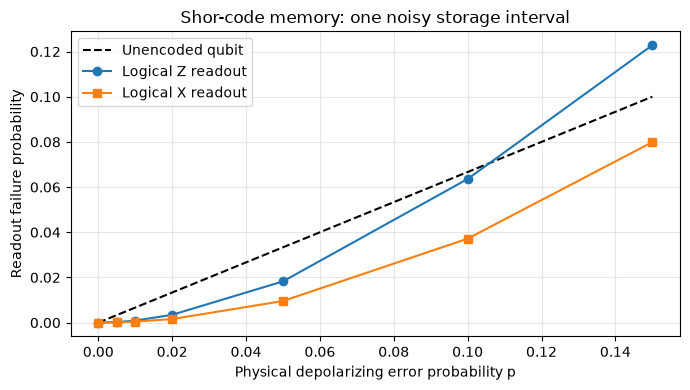

In [34]:
data = np.array(results)
p_values = data[:, 0]

fig, ax = plt.subplots(figsize=(7, 4))

ax.plot(p_values, 2 * p_values / 3, "--", color="black",
        label="Unencoded qubit")
ax.plot(p_values, data[:, 1], "o-", label="Logical Z readout")
ax.plot(p_values, data[:, 2], "s-", label="Logical X readout")

ax.set(
    xlabel="Physical depolarizing error probability p",
    ylabel="Readout failure probability",
    title="Shor-code memory: one noisy storage interval",
)
ax.grid(alpha=0.3)
ax.legend()
plt.tight_layout()
plt.show()

A logical curve below the unencoded reference indicates improved memory performance in that basis.

Because the decoder corrects every single-qubit Pauli error, failures require at least two physical errors. We therefore expect $p_L=O(p^2)$ at small $p$, under these ideal-measurement assumptions.

The two curves measure different logical failure events; neither alone is the probability of any logical error. Their estimates fluctuate with finite sampling, and zero observed failures does not prove zero failure probability.